###Customer Lifetime Value (CLTV) Analysis
**Objective**

The objective of this notebook is to estimate Customer Lifetime Value (CLTV) using the cleaned Olist e-commerce dataset prepared during the data cleaning phase.

This analysis helps identify high-value customers by examining their purchasing behaviour, revenue contribution, and ordering frequency. The results can be used for customer retention strategies, personalised marketing campaigns, and business decision-making.

###load libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

###Load dataset

In [2]:
df = pd.read_csv('analysis data.csv')

###Dataset shape

In [30]:
df.shape

(14421, 39)

###All columns

In [21]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'revenue',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'purchase_year',
 'purchase_month',
 'purchase_quarter',
 'purchase_day',
 'delivery_days',
 'delivery_delay',
 'delivery_status']

###Dataset Informations

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14421 entries, 0 to 14420
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       14421 non-null  object 
 1   customer_id                    14420 non-null  object 
 2   order_status                   14420 non-null  object 
 3   order_purchase_timestamp       14420 non-null  object 
 4   order_approved_at              14420 non-null  object 
 5   order_delivered_carrier_date   14420 non-null  object 
 6   order_delivered_customer_date  14420 non-null  object 
 7   order_estimated_delivery_date  14420 non-null  object 
 8   customer_unique_id             14420 non-null  object 
 9   customer_zip_code_prefix       14420 non-null  float64
 10  customer_city                  14420 non-null  object 
 11  customer_state                 14420 non-null  object 
 12  order_item_id                  14420 non-null 

In [24]:
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,revenue,payment_sequential,payment_installments,payment_value,product_name_lenght,product_description_lenght,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,purchase_year,purchase_month,purchase_quarter,purchase_day,delivery_days,delivery_delay
count,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000,14420.00000,14420.000000,14420.000000,...,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000,14420.000000
mean,34831.019972,0.972469,99.543225,16.430262,99.543225,1.089251,2.933564,169.82693,49.219487,757.133287,...,1860.025173,29.332871,16.011997,22.443689,2017.539182,6.019209,2.348821,15.634674,11.960333,-11.942025
std,29578.320587,0.701819,178.631474,15.757525,178.631474,0.664462,2.757966,245.42636,9.441753,594.803100,...,3420.786214,14.891317,12.480478,10.946437,0.504702,3.252656,1.068415,8.716197,9.169348,9.783259
min,1003.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.00000,10.000000,20.000000,...,0.000000,7.000000,2.000000,9.000000,2016.000000,1.000000,1.000000,1.000000,0.000000,-69.000000
25%,11700.000000,1.000000,23.100000,8.720000,23.100000,1.000000,1.000000,61.37750,45.000000,396.000000,...,350.000000,19.000000,10.000000,15.000000,2017.000000,3.000000,1.000000,8.000000,6.000000,-17.000000
50%,24040.000000,1.000000,59.000000,15.110000,59.000000,1.000000,2.000000,106.80500,52.000000,601.000000,...,700.000000,25.000000,13.000000,20.000000,2018.000000,6.000000,2.000000,16.000000,10.000000,-13.000000
75%,58033.000000,1.000000,118.762500,19.320000,118.762500,1.000000,4.000000,186.65500,56.000000,895.000000,...,1500.000000,35.000000,19.000000,26.000000,2018.000000,8.000000,3.000000,23.000000,15.000000,-7.000000
max,99950.000000,12.000000,4399.870000,322.100000,4399.870000,22.000000,24.000000,6726.66000,64.000000,3988.000000,...,30000.000000,105.000000,105.000000,104.000000,2018.000000,12.000000,4.000000,31.000000,191.000000,175.000000


In [3]:
df[['customer_state','revenue']].head()

,customer_state,revenue
0,SP,0.0
1,SP,0.0
2,SP,0.0
3,BA,118.7
4,GO,159.9


###Total Revenue generated by each state

In [4]:
state_revenue = (
    df.groupby('customer_state')
      ['revenue']
      .sum()
      .reset_index()
)

state_revenue

,customer_state,revenue
0,AC,2565.44
1,AL,5246.14
2,AM,1808.67
3,AP,214.89
4,BA,53125.45
5,CE,28792.91
6,DF,33982.32
7,ES,25834.67
8,GO,32122.51
9,MA,18012.89


In [5]:
state_revenue['Revenue_Level'] = pd.qcut(
    state_revenue['revenue'],
    q=3,
    labels=[
        'Low Revenue',
        'Medium Revenue',
        'High Revenue'
    ]
)

In [6]:
state_revenue.sort_values(
    'revenue',
    ascending=False
)

,customer_state,revenue,Revenue_Level
25,SP,554321.33,High Revenue
18,RJ,200124.46,High Revenue
10,MG,152495.78,High Revenue
17,PR,79086.32,High Revenue
22,RS,73556.73,High Revenue
23,SC,57224.64,High Revenue
4,BA,53125.45,High Revenue
6,DF,33982.32,High Revenue
8,GO,32122.51,High Revenue
5,CE,28792.91,Medium Revenue


In [7]:
heatmap_data = pd.pivot_table(
    state_revenue,
    values='revenue',
    index='customer_state',
    columns='Revenue_Level',
    aggfunc='sum',
    fill_value=0
)

/tmp/ipykernel_3680/2544646157.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = pd.pivot_table(


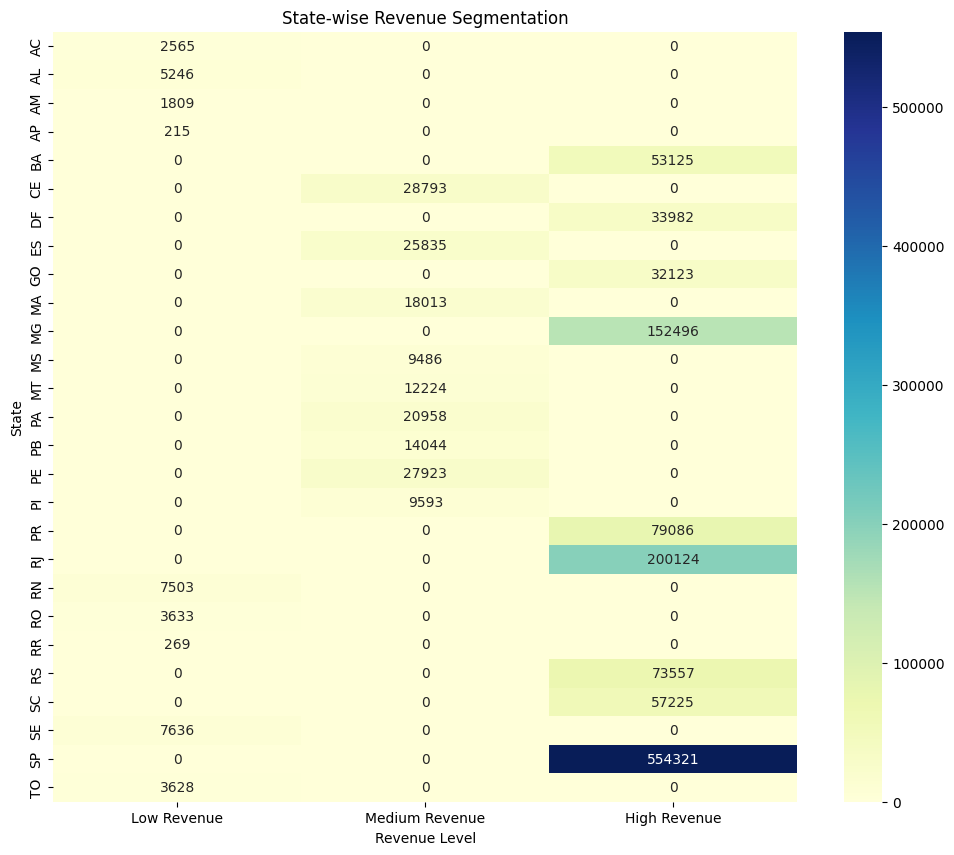

In [8]:
plt.figure(figsize=(12,10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title(
    'State-wise Revenue Segmentation'
)

plt.xlabel('Revenue Level')
plt.ylabel('State')

plt.show()

###High revenue generated state

In [9]:
high_states = state_revenue[
    state_revenue['Revenue_Level']
    == 'High Revenue'
]

print(high_states)

   customer_state    revenue Revenue_Level
4              BA   53125.45  High Revenue
6              DF   33982.32  High Revenue
8              GO   32122.51  High Revenue
10             MG  152495.78  High Revenue
17             PR   79086.32  High Revenue
18             RJ  200124.46  High Revenue
22             RS   73556.73  High Revenue
23             SC   57224.64  High Revenue
25             SP  554321.33  High Revenue


###Medium revenue generated state

In [10]:
medium_states = state_revenue[
    state_revenue['Revenue_Level']
    == 'Medium Revenue'
]

print(medium_states)

   customer_state   revenue   Revenue_Level
5              CE  28792.91  Medium Revenue
7              ES  25834.67  Medium Revenue
9              MA  18012.89  Medium Revenue
11             MS   9486.35  Medium Revenue
12             MT  12223.67  Medium Revenue
13             PA  20957.71  Medium Revenue
14             PB  14044.30  Medium Revenue
15             PE  27923.36  Medium Revenue
16             PI   9593.05  Medium Revenue


###Low Revenue Generated State

In [11]:
low_states = state_revenue[
    state_revenue['Revenue_Level']
    == 'Low Revenue'
]

print(low_states)

   customer_state  revenue Revenue_Level
0              AC  2565.44   Low Revenue
1              AL  5246.14   Low Revenue
2              AM  1808.67   Low Revenue
3              AP   214.89   Low Revenue
19             RN  7503.33   Low Revenue
20             RO  3633.42   Low Revenue
21             RR   269.27   Low Revenue
24             SE  7635.68   Low Revenue
26             TO  3628.01   Low Revenue


###Top customers in each state


In [12]:
customer_revenue = (
    df.groupby(
        ['customer_state', 'customer_unique_id']
    )['revenue']
    .sum()
    .reset_index()
)

customer_revenue.rename(
    columns={'revenue':'Total_Revenue'},
    inplace=True
)

customer_revenue.head()

,customer_state,customer_unique_id,Total_Revenue
0,AC,3168dc37da92585ed2bf29058b0cc143,56.99
1,AC,36db357344c8891e84f88e8d3ae4c538,88.34
2,AC,3e5c928acf49c4b95e57af1f350d3493,809.10
3,AC,4b6d726a54a2660c4d09bd675d37a813,50.00
4,AC,50881a1a7cf12940a91d1f5738e373df,285.00


In [13]:
top10_state_customers = (
    customer_revenue
    .groupby('customer_state', group_keys=False)
    .apply(
        lambda x: x.nlargest(
            10,
            'Total_Revenue'
        )
    )
)

top10_state_customers.head()

/tmp/ipykernel_3680/218214509.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,customer_state,customer_unique_id,Total_Revenue
2,AC,3e5c928acf49c4b95e57af1f350d3493,809.10
6,AC,785a8a410d6fc9661d66f7218a87229d,300.00
4,AC,50881a1a7cf12940a91d1f5738e373df,285.00
10,AC,d5a9eccfa0ca0ec79d59b81e98d83911,249.99
13,AC,df55ce6c8cb70b6d287154e726ad9066,239.00


In [14]:
print(
    "Total Customers Collected:",
    len(top10_state_customers)
)

Total Customers Collected: 261


In [15]:
overall_top10 = (
    top10_state_customers
    .sort_values(
        'Total_Revenue',
        ascending=False
    )
    .head(10)
)

overall_top10

,customer_state,customer_unique_id,Total_Revenue
912,DF,edf81e1f3070b9dac83ec83dacdbb9bc,7998.00
12025,SP,edde2314c6c30e864a128ac95d6b2112,4399.87
2650,MG,ca27f3dac28fb1063faddd424c9d95fa,4059.00
10309,SP,9b11e010850a4045d2da80c7783fdbd1,3198.00
6958,SC,bbeb907759ef5fc169099af3c88d535d,3105.00
1985,MG,53fb3435773a4690e56010b169ee2820,3099.90
1449,MA,1b76903617af13189607a36b0469f6f3,3099.75
3938,PR,895617ab63a9ad8881d9470f7427cd25,2999.99
4841,RJ,6172bd5b7f52ade8c6c4548b448ff54f,2999.89
609,CE,7efc49d7862ee114c0ca869b439bf381,2874.00


###Top 10 customers  

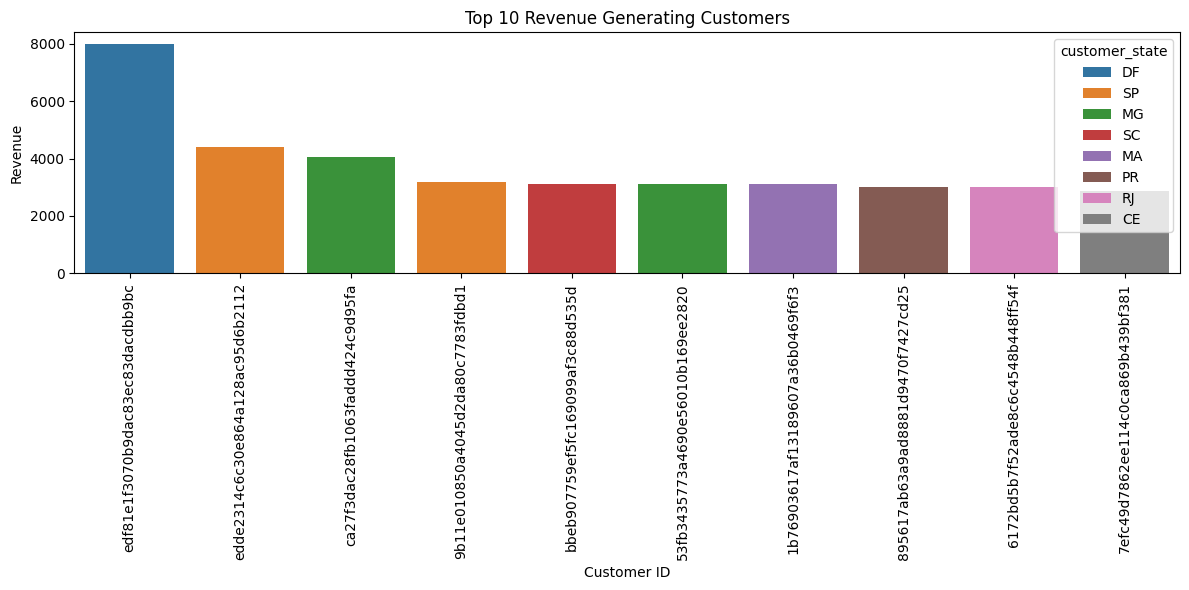

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=overall_top10,
    x='customer_unique_id',
    y='Total_Revenue',
    hue='customer_state'
)

plt.xticks(rotation=90)

plt.title(
    'Top 10 Revenue Generating Customers'
)

plt.xlabel('Customer ID')
plt.ylabel('Revenue')

plt.tight_layout()

plt.show()

In [17]:
overall_top10.reset_index(
    drop=True,
    inplace=True
)

overall_top10.index += 1

overall_top10

,customer_state,customer_unique_id,Total_Revenue
1,DF,edf81e1f3070b9dac83ec83dacdbb9bc,7998.00
2,SP,edde2314c6c30e864a128ac95d6b2112,4399.87
3,MG,ca27f3dac28fb1063faddd424c9d95fa,4059.00
4,SP,9b11e010850a4045d2da80c7783fdbd1,3198.00
5,SC,bbeb907759ef5fc169099af3c88d535d,3105.00
6,MG,53fb3435773a4690e56010b169ee2820,3099.90
7,MA,1b76903617af13189607a36b0469f6f3,3099.75
8,PR,895617ab63a9ad8881d9470f7427cd25,2999.99
9,RJ,6172bd5b7f52ade8c6c4548b448ff54f,2999.89
10,CE,7efc49d7862ee114c0ca869b439bf381,2874.00


###Calculate Orders per Customer per State

In [25]:
customer_orders = (
    df.groupby(
        ['customer_state', 'customer_unique_id']
    )['order_id']
    .nunique()
    .reset_index()
)

customer_orders.rename(
    columns={'order_id':'Total_Orders'},
    inplace=True
)

customer_orders.head()

,customer_state,customer_unique_id,Total_Orders
0,AC,3168dc37da92585ed2bf29058b0cc143,1
1,AC,36db357344c8891e84f88e8d3ae4c538,1
2,AC,3e5c928acf49c4b95e57af1f350d3493,1
3,AC,4b6d726a54a2660c4d09bd675d37a813,1
4,AC,50881a1a7cf12940a91d1f5738e373df,1


In [26]:
top10_state_orders = (
    customer_orders
    .groupby('customer_state', group_keys=False)
    .apply(
        lambda x: x.nlargest(
            10,
            'Total_Orders'
        )
    )
)

top10_state_orders.head()

/tmp/ipykernel_3680/1665417673.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,customer_state,customer_unique_id,Total_Orders
0,AC,3168dc37da92585ed2bf29058b0cc143,1
1,AC,36db357344c8891e84f88e8d3ae4c538,1
2,AC,3e5c928acf49c4b95e57af1f350d3493,1
3,AC,4b6d726a54a2660c4d09bd675d37a813,1
4,AC,50881a1a7cf12940a91d1f5738e373df,1


In [27]:
overall_top10_orders = (
    top10_state_orders
    .sort_values(
        'Total_Orders',
        ascending=False
    )
    .head(10)
)

overall_top10_orders

,customer_state,customer_unique_id,Total_Orders
10014,SP,8d50f5eadf50201ccdcedfb9e2ac8455,4
8556,SP,43f9d5ace80c6d3c5c09544bc2fa8484,2
8167,SP,30b782a79466007756f170cb5bd6bbd8,2
8574,SP,44bd7571a7dad968306f7776bd5a5745,2
7210,SP,041caba6a63ace5818387698ea85cdb2,2
7861,SP,23b2d37ef78f3c8dcb31f5eefc30190a,2
109,BA,08c07c761592a71b85136aa4fe76a6f4,2
404,BA,c2551ea089b7ebbc67a2ea8757152514,2
484,BA,f0fd988c7c2a4cba167138a8adada6ca,2
6920,SC,a54a1749bd03dfe0d3642b7fbd888b47,2


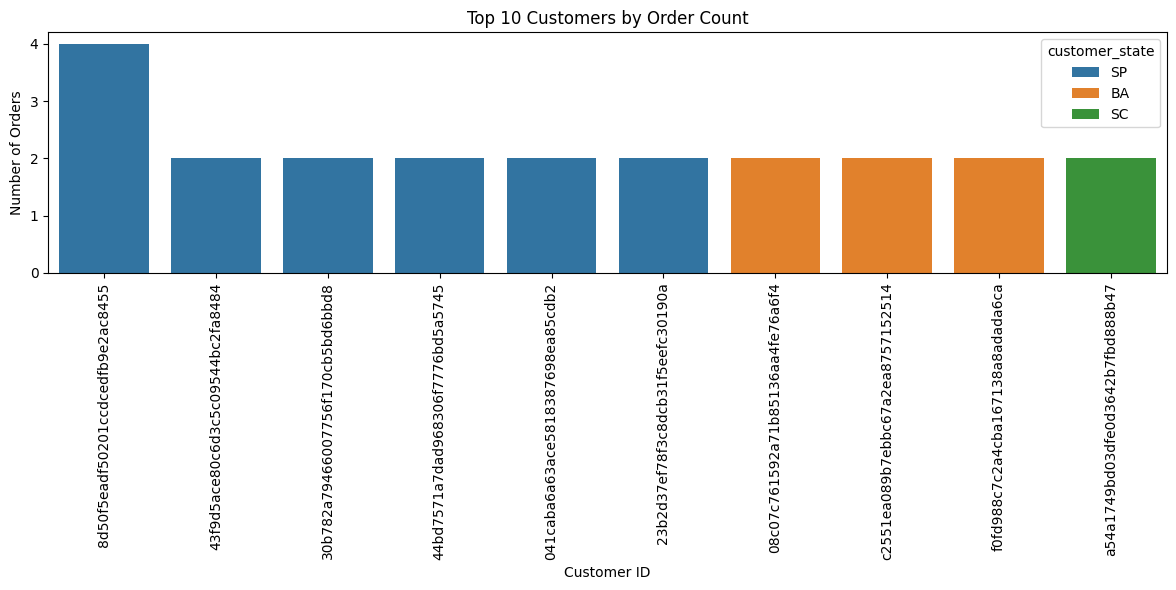

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=overall_top10_orders,
    x='customer_unique_id',
    y='Total_Orders',
    hue='customer_state'
)

plt.xticks(rotation=90)

plt.title(
    'Top 10 Customers by Order Count'
)

plt.xlabel('Customer ID')
plt.ylabel('Number of Orders')

plt.tight_layout()

plt.show()